In [2]:
import numpy as np
import pandas as pd

In [3]:
fac = pd.read_csv("09_fac.csv")
trained_com = pd.read_csv("09_tch.csv")

In [ ]:
data = fac[["pseudocode", "desktop"]].merge(
    trained_com[["pseudocode", "trained_comp"]],
    on="pseudocode",
    how="inner"
).dropna()

sample_sizes = [10, 20, 100, 250, 500]
rng = np.random.default_rng(42)

results = []

for size in sample_sizes:
    for sample_num in range(1, 11):
        sample = data.sample(n=size, random_state=int(rng.integers(0, 1_000_000)))

        results.append({
            "sample_id": f"{size}_{sample_num}",
            "sample_size": size,
            "desktop_mean": sample["desktop"].mean(),
            "desktop_variance": sample["desktop"].var(),
            "trained_comp_mean": sample["trained_comp"].mean(),
            "trained_comp_variance": sample["trained_comp"].var(),
            "correlation": sample["desktop"].corr(sample["trained_comp"],method='spearman')
        })

results_df = pd.DataFrame(results)

results_df

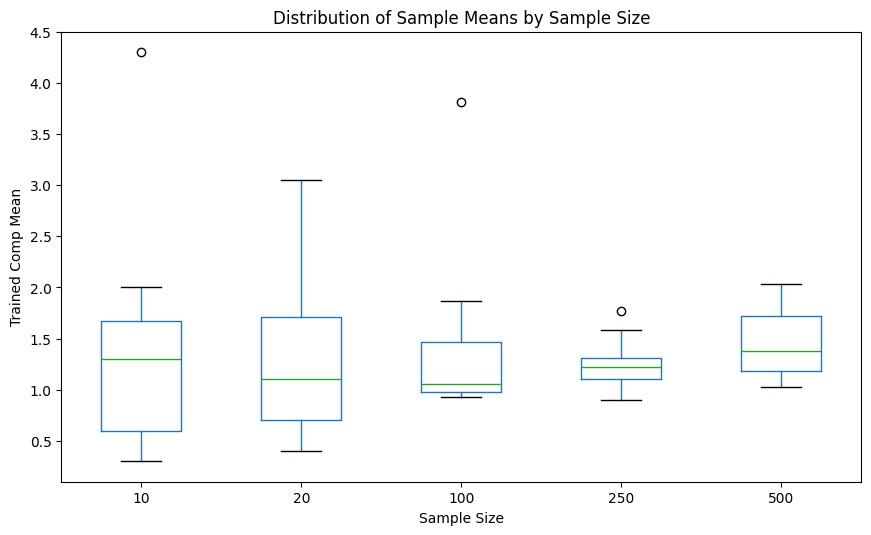

In [ ]:
import matplotlib.pyplot as plt

results_df.boxplot(
    column="trained_comp_mean",
    by="sample_size",
    grid=False,
    figsize=(10, 6)
)

plt.title("Distribution of Sample Means by Sample Size")
plt.suptitle("")
plt.xlabel("Sample Size")
plt.ylabel("Trained Comp Mean")
plt.show()

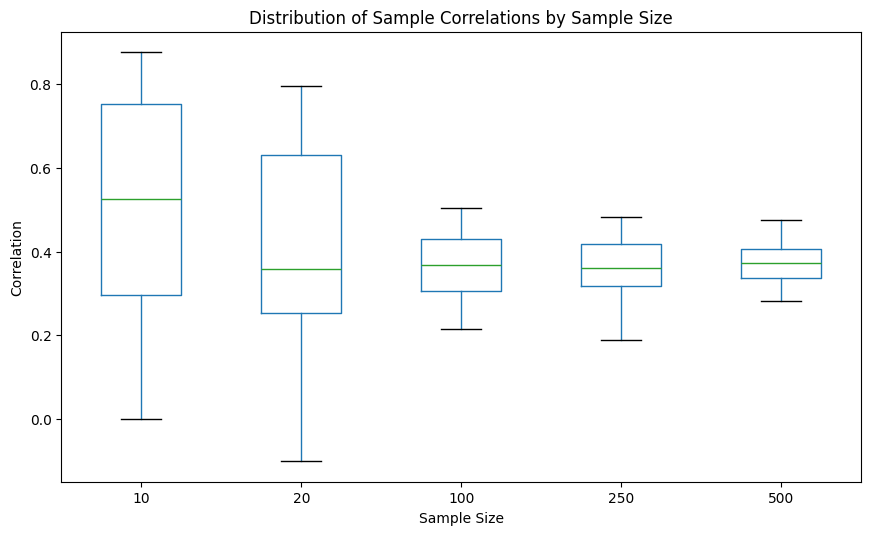

In [ ]:
import matplotlib.pyplot as plt

results_df.boxplot(
    column="correlation",
    by="sample_size",
    grid=False,
    figsize=(10, 6)
)

plt.title("Distribution of Sample Correlations by Sample Size")
plt.suptitle("")
plt.xlabel("Sample Size")
plt.ylabel("Correlation")
plt.show()

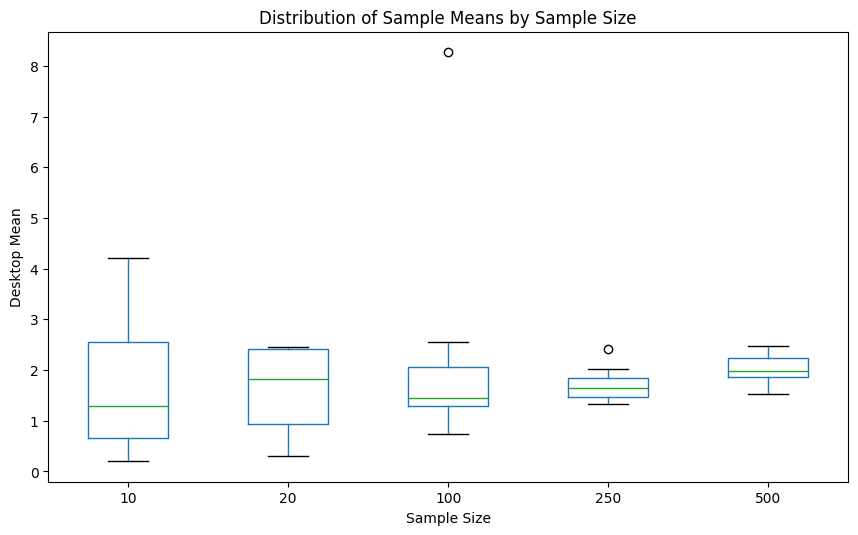

In [ ]:
import matplotlib.pyplot as plt

results_df.boxplot(
    column="desktop_mean",
    by="sample_size",
    grid=False,
    figsize=(10, 6)
)

plt.title("Distribution of Sample Means by Sample Size")
plt.suptitle("")
plt.xlabel("Sample Size")
plt.ylabel("Desktop Mean")
plt.show()

In [ ]:
sample_sizes = [10, 15, 20, 25, 30, 50, 100, 200, 250]
n_samples = 10

sample_results = []

for sample_num in range(n_samples):
    for sample_size in sample_sizes:
        sampled_data = data.sample(
            n=sample_size,
            random_state=int(rng.integers(0, 1_000_000))
        )

        sample_results.append({
            "sample_num": sample_num + 1,
            "sample_size": sample_size,
            "desktop_mean": sampled_data["desktop"].mean(),
            "trained_comp_mean": sampled_data["trained_comp"].mean(),
            "correlation": sampled_data["desktop"].corr(
                sampled_data["trained_comp"],
                method="spearman"
            )
        })

sampling_results_df = pd.DataFrame(sample_results)

# Means: 10 graphs in a 2x5 layout
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True)
axes = axes.ravel()

for sample_num, ax in enumerate(axes, start=1):
    subset = sampling_results_df[
        sampling_results_df["sample_num"] == sample_num
    ]

    ax.plot(
        subset["sample_size"],
        subset["desktop_mean"],
        marker="o",
        label="Desktop"
    )
    ax.plot(
        subset["sample_size"],
        subset["trained_comp_mean"],
        marker="o",
        label="Trained Comp"
    )

    ax.set_title(f"Sample {sample_num}")
    ax.set_xlabel("Sample Size")
    ax.set_ylabel("Mean")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("Sample Means by Sample Size", fontsize=16)
plt.tight_layout()
plt.show()

# Means: 10 graphs in a 2x5 layout
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True)
axes = axes.ravel()

# Same Y-axis scale for every graph
mean_min = min(
    sampling_results_df["desktop_mean"].min(),
    sampling_results_df["trained_comp_mean"].min()
)
mean_max = max(
    sampling_results_df["desktop_mean"].max(),
    sampling_results_df["trained_comp_mean"].max()
)

for sample_num, ax in enumerate(axes, start=1):
    subset = sampling_results_df[
        sampling_results_df["sample_num"] == sample_num
    ]

    ax.plot(
        subset["sample_size"],
        subset["desktop_mean"],
        marker="o",
        label="Desktop"
    )
    ax.plot(
        subset["sample_size"],
        subset["trained_comp_mean"],
        marker="o",
        label="Trained Comp"
    )

    ax.set_title(f"Sample {sample_num}")
    ax.set_xlabel("Sample Size")
    ax.set_ylabel("Mean")
    ax.set_ylim(mean_min, mean_max)   # SAME Y SCALE
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("Sample Means by Sample Size", fontsize=16)
plt.tight_layout()
plt.show()

NameError: name 'data' is not defined

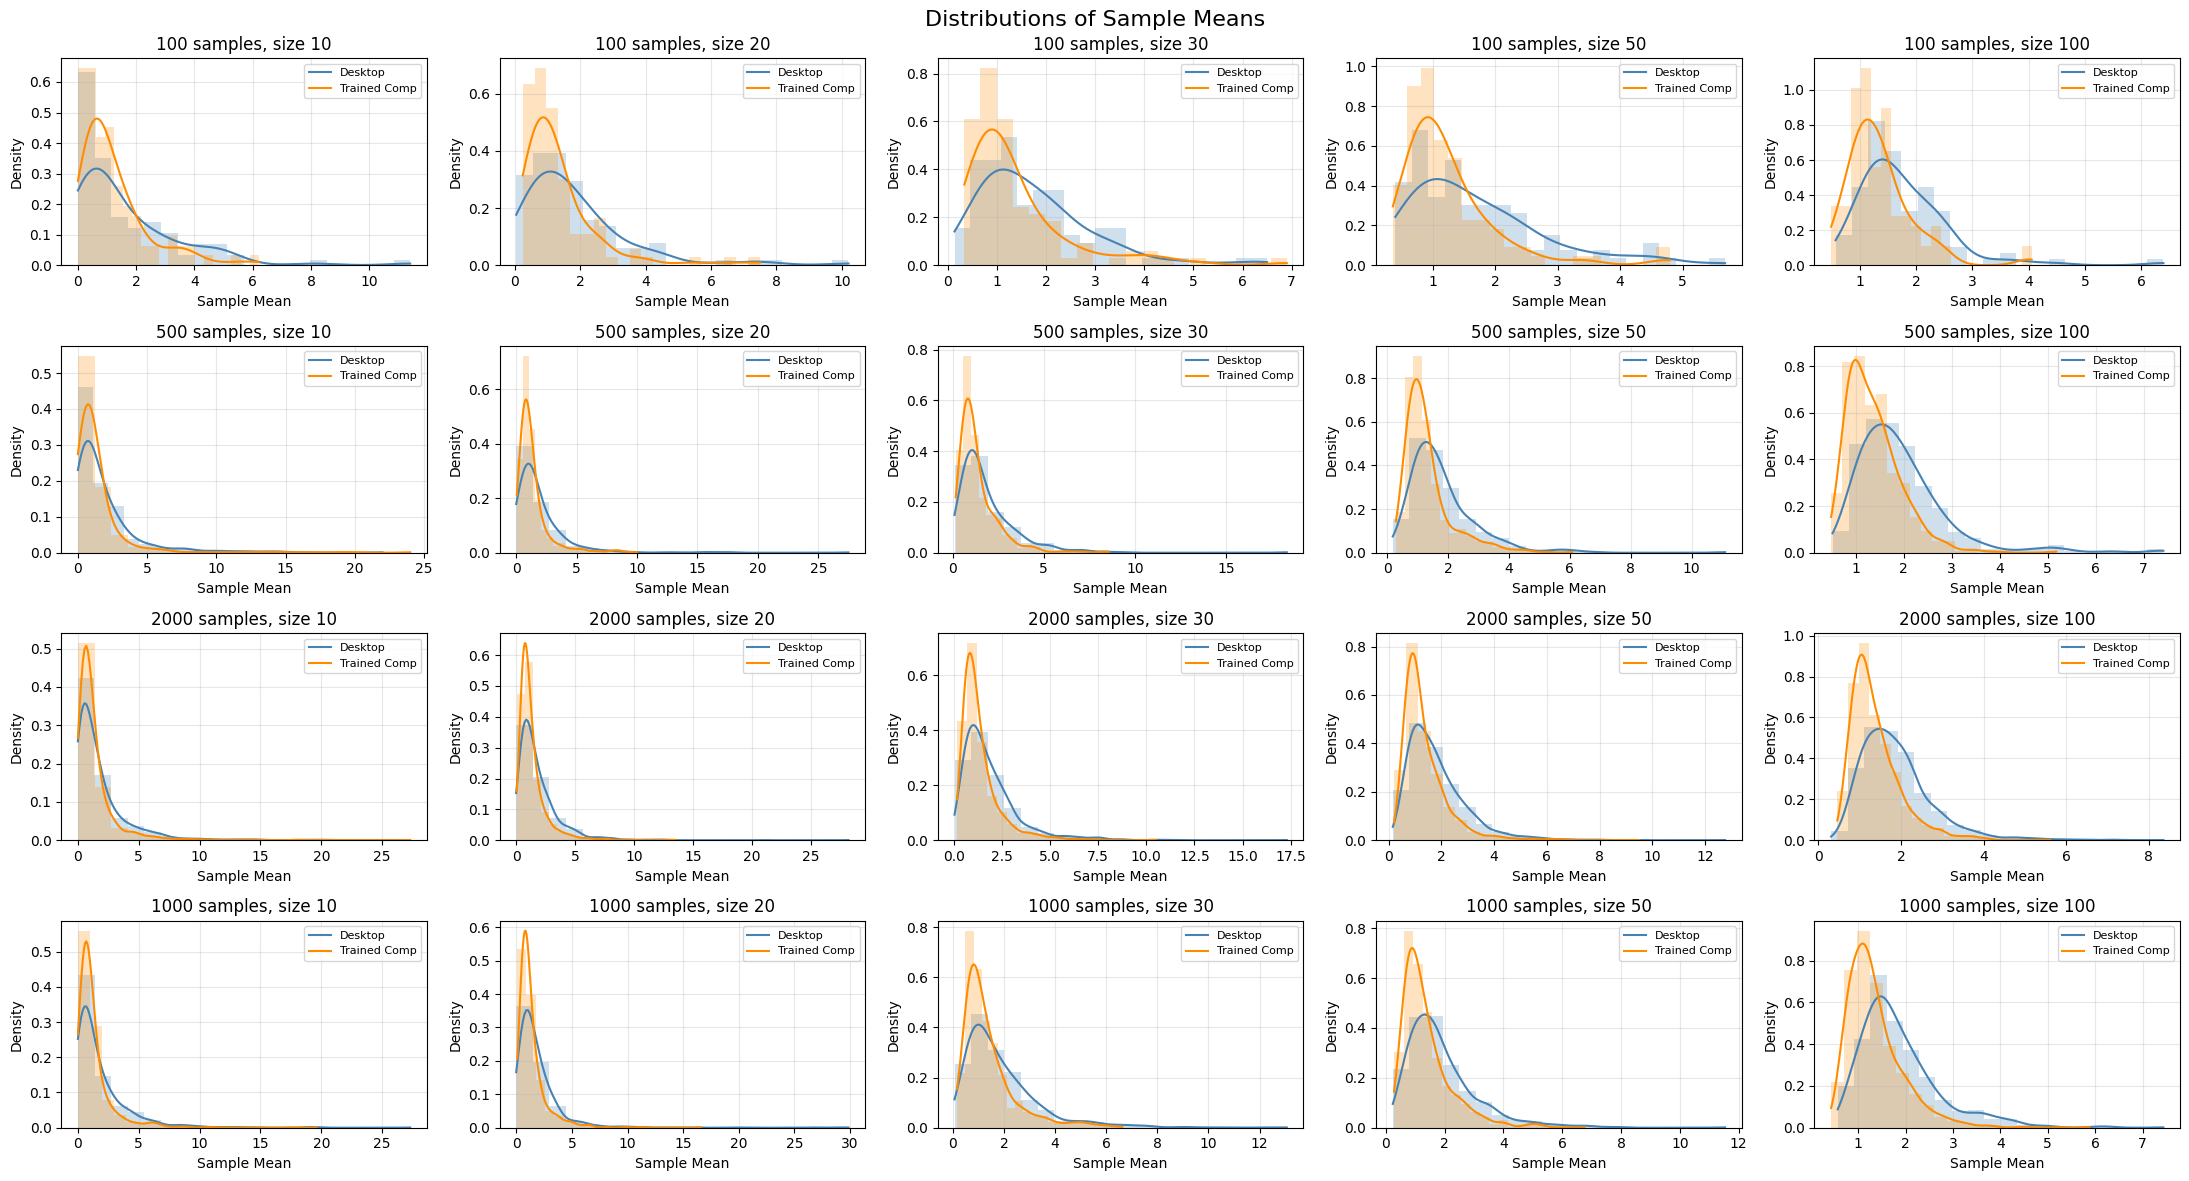

In [ ]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sample_sizes = [10, 20, 30, 50, 100]
sample_counts = [100, 500, 2000,1000]

mean_results = []

for n_samples in sample_counts:
    for sample_size in sample_sizes:
        for _ in range(n_samples):
            sampled = data.sample(
                n=sample_size,
                random_state=int(rng.integers(0, 1_000_000))
            )

            mean_results.append({
                "n_samples": n_samples,
                "sample_size": sample_size,
                "desktop_mean": sampled["desktop"].mean(),
                "trained_comp_mean": sampled["trained_comp"].mean()
            })

means_df = pd.DataFrame(mean_results)

fig, axes = plt.subplots(
    4, 5,
    figsize=(22, 12),
    sharex=False,
    sharey=False
)

for row, n_samples in enumerate(sample_counts):
    for col, sample_size in enumerate(sample_sizes):

        ax = axes[row, col]

        subset = means_df[
            (means_df["n_samples"] == n_samples) &
            (means_df["sample_size"] == sample_size)
        ]

        for column, label, color in [
            ("desktop_mean", "Desktop", "steelblue"),
            ("trained_comp_mean", "Trained Comp", "darkorange")
        ]:

            values = subset[column].dropna().to_numpy()

            # Histogram
            ax.hist(
                values,
                bins=20,
                density=True,
                alpha=0.25,
                color=color
            )

            # KDE
            # KDE requires at least 2 different values
            if values.size > 1 and values.min() != values.max():

                x = np.linspace(
                    values.min(),
                    values.max(),
                    200
                )

                kde = gaussian_kde(values)

                ax.plot(
                    x,
                    kde(x),
                    color=color,
                    label=label
                )

            # If all values are identical, show a vertical line instead
            elif values.size > 0:

                ax.axvline(
                    values[0],
                    color=color,
                    linestyle="--",
                    label=label
                )

        ax.set_title(
            f"{n_samples} samples, size {sample_size}"
        )

        ax.set_xlabel("Sample Mean")
        ax.set_ylabel("Density")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

fig.suptitle(
    "Distributions of Sample Means",
    fontsize=16
)

plt.tight_layout()
plt.show()